In [19]:
import os
import time
import pandas as pd

os.environ['JAVA_HOME'] = '/usr/local/sdkman/candidates/java/current'
os.environ['PATH'] = os.environ['JAVA_HOME'] + '/bin:' + os.environ['PATH']

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder


spark = SparkSession.builder \
    .appName("ModeleImmo") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print("Spark OK :", spark.version)

Spark OK : 3.5.0


In [20]:
bases_fusionnees = spark.read.csv("bases_fusionnees.csv", header=True, inferSchema=True, sep=",")


In [21]:
bases_fusionnees.printSchema()

root
 |-- type_bien: string (nullable = true)
 |-- pieces: double (nullable = true)
 |-- prix: double (nullable = true)
 |-- surface: double (nullable = true)
 |-- etage: string (nullable = true)
 |-- ville: string (nullable = true)
 |-- code_postal: integer (nullable = true)



In [22]:
print("Colonnes :", bases_fusionnees.columns)

Colonnes : ['type_bien', 'pieces', 'prix', 'surface', 'etage', 'ville', 'code_postal']


In [23]:

bases_fusionnees.describe().show()
bases_fusionnees.groupBy("type_bien").count().orderBy(F.desc("count")).show()
bases_fusionnees.groupBy("pieces").count().orderBy("pieces").show()
bases_fusionnees.groupBy("ville").count().orderBy(F.desc("count")).show(10)

+-------+-----------+------------------+-----------------+------------------+------------------+------+------------------+
|summary|  type_bien|            pieces|             prix|           surface|             etage| ville|       code_postal|
+-------+-----------+------------------+-----------------+------------------+------------------+------+------------------+
|  count|       8019|              8019|             8019|              8019|              8019|  8019|              8019|
|   mean|       NULL|  4.05100386581868|427315.1996508293|101.58756702830776|2.8797779201366644|  NULL|  69273.8709315376|
| stddev|       NULL|1.6509496507084573|300296.6495465243| 61.13174260486775|  2.33179621631308|  NULL|252.03671516019935|
|    min|appartement|               1.0|          49000.0|               9.0|                -1|affoux|             69001|
|    max|     maison|              12.0|        4160000.0|             900.0|               RDC| éveux|             69970|
+-------+-------

In [24]:
bases_fusionnees.groupBy("etage").count().orderBy(F.desc("count")).show(30)

+------+-----+
| etage|count|
+------+-----+
|MAISON| 2525|
|     1| 1660|
|     2|  969|
|   RDC|  811|
|     3|  730|
|     4|  487|
|     5|  312|
|     6|  170|
|     7|  126|
|     8|   76|
|     9|   52|
|    12|   22|
|    10|   20|
|    11|   18|
|    13|   17|
|    15|    8|
|    14|    8|
|    16|    4|
|    -1|    2|
|    18|    1|
|    17|    1|
+------+-----+



In [25]:
train_data, test_data = bases_fusionnees.randomSplit([0.8, 0.2], seed=42)
train_data = train_data.cache()
test_data  = test_data.cache()
print(f"Taille train : {train_data.count()} lignes")
print(f"Taille test  : {test_data.count()} lignes")

Taille train : 6486 lignes
Taille test  : 1533 lignes


In [26]:
# Encodage 
indexer_ville = StringIndexer(inputCol="ville",     outputCol="ville_idx", handleInvalid="keep")
indexer_type  = StringIndexer(inputCol="type_bien", outputCol="type_idx",  handleInvalid="keep")
indexer_etage = StringIndexer(inputCol="etage",     outputCol="etage_idx", handleInvalid="keep")

assembler = VectorAssembler(
    inputCols=["type_idx", "pieces", "surface", "etage_idx", "ville_idx", "code_postal"],
    outputCol="features"
)

print("Features : type_idx, pieces, surface, etage_idx, ville_idx, code_postal")

Features : type_idx, pieces, surface, etage_idx, ville_idx, code_postal


In [27]:
# Evualteur
evaluator = RegressionEvaluator(labelCol="prix", predictionCol="prediction", metricName="r2")
rmse_eval = RegressionEvaluator(labelCol="prix", predictionCol="prediction", metricName="rmse")
mae_eval  = RegressionEvaluator(labelCol="prix", predictionCol="prediction", metricName="mae")

In [28]:
from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(featuresCol="features", labelCol="prix", maxBins=256, seed=42)
pipeline_dt = Pipeline(stages=[indexer_ville, indexer_type, indexer_etage, assembler, dt])

param_grid_dt = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [5, 8, 12]) \
    .build()

cv_dt = CrossValidator(
    estimator=pipeline_dt,
    estimatorParamMaps=param_grid_dt,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("Entraînement Decision Tree CV (3 configs x 5 folds)...")
cv_model_dt = cv_dt.fit(train_data)
best_depth_dt = cv_model_dt.bestModel.stages[-1].getMaxDepth()
print(f"Meilleur maxDepth : {best_depth_dt}")
print(f"Scores CV moyens  : {[round(s,4) for s in cv_model_dt.avgMetrics]}")

Entraînement Decision Tree CV (3 configs x 5 folds)...


Meilleur maxDepth : 5
Scores CV moyens  : [np.float64(0.6277), np.float64(0.5279), np.float64(0.4176)]


In [29]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(featuresCol="features", labelCol="prix", maxBins=256, seed=42)
pipeline_rf = Pipeline(stages=[indexer_ville, indexer_type, indexer_etage, assembler, rf])

param_grid_rf = ParamGridBuilder() \
    .addGrid(rf.maxDepth,  [8, 12]) \
    .addGrid(rf.numTrees,  [50, 100]) \
    .build()

cv_rf = CrossValidator(
    estimator=pipeline_rf,
    estimatorParamMaps=param_grid_rf,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("Entraînement Random Forest CV (4 configs x 5 folds)...")
cv_model_rf = cv_rf.fit(train_data)
best_rf = cv_model_rf.bestModel.stages[-1]
print(f"Meilleur numTrees : {best_rf.getNumTrees}")
print(f"Meilleur maxDepth : {best_rf.getMaxDepth()}")
print(f"Scores CV moyens  : {[round(s,4) for s in cv_model_rf.avgMetrics]}")

Entraînement Random Forest CV (4 configs x 5 folds)...


Meilleur numTrees : 100
Meilleur maxDepth : 8
Scores CV moyens  : [np.float64(0.6504), np.float64(0.6602), np.float64(0.622), np.float64(0.6349)]


In [30]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(featuresCol="features", labelCol="prix", maxBins=256, seed=42)
pipeline_gbt = Pipeline(stages=[indexer_ville, indexer_type, indexer_etage, assembler, gbt])

param_grid_gbt = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [5, 8]) \
    .addGrid(gbt.stepSize, [0.05, 0.1]) \
    .build()

cv_gbt = CrossValidator(
    estimator=pipeline_gbt,
    estimatorParamMaps=param_grid_gbt,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("Entraînement GBT CV")
cv_model_gbt = cv_gbt.fit(train_data)
best_gbt = cv_model_gbt.bestModel.stages[-1]
print(f"Meilleur maxDepth : {best_gbt.getMaxDepth()}")
print(f"Meilleur stepSize : {best_gbt.getStepSize()}")
print(f"Scores CV moyens  : {[round(s,4) for s in cv_model_gbt.avgMetrics]}")

Entraînement GBT CV
Meilleur maxDepth : 5
Meilleur stepSize : 0.05
Scores CV moyens  : [np.float64(0.6032), np.float64(0.5645), np.float64(0.495), np.float64(0.4712)]


In [31]:
dt_pred  = cv_model_dt.transform(test_data)
rf_pred  = cv_model_rf.transform(test_data)
gbt_pred = cv_model_gbt.transform(test_data)

resultats = pd.DataFrame({
    "Modele":["Decision Tree CV", "Random Forest CV", "GBT CV"],
    "R2":[round(evaluator.evaluate(dt_pred), 4),
                     round(evaluator.evaluate(rf_pred), 4),
                     round(evaluator.evaluate(gbt_pred), 4)],
    "RMSE (euros)": [round(rmse_eval.evaluate(dt_pred)),
                     round(rmse_eval.evaluate(rf_pred)),
                     round(rmse_eval.evaluate(gbt_pred))],
    "MAE (euros)":  [round(mae_eval.evaluate(dt_pred)),
                     round(mae_eval.evaluate(rf_pred)),
                     round(mae_eval.evaluate(gbt_pred))]
})



meilleur_idx = resultats['R2'].idxmax()
meilleur     = resultats.loc[meilleur_idx]
print(f"Meilleur modèle : {meilleur['Modele']}")
print(f"   R2   : {meilleur['R2']}")
print(f"   RMSE : {meilleur['RMSE (euros)']:,} €")
print(f"   MAE  : {meilleur['MAE (euros)']:,} €")

Meilleur modèle : Random Forest CV
   R2   : 0.6957
   RMSE : 169,602 €
   MAE  : 97,815 €


In [32]:
import numpy as np

feature_names = ["type_idx", "pieces", "surface", "etage_idx", "ville_idx", "code_postal"]


best_rf_model = cv_model_rf.bestModel.stages[-1]
importances_rf = best_rf_model.featureImportances.toArray()

fi_df = pd.DataFrame({
    "Variable":   feature_names,
    "Importance": importances_rf
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Feature Importances:Random Forest")
print(fi_df.to_string(index=False))

best_gbt_model = cv_model_gbt.bestModel.stages[-1]
importances_gbt = best_gbt_model.featureImportances.toArray()

fi_gbt = pd.DataFrame({
    "Variable":   feature_names,
    "Importance": importances_gbt
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("Feature Importances")
print(fi_gbt.to_string(index=False))

Feature Importances:Random Forest
   Variable  Importance
    surface    0.441244
  ville_idx    0.226734
     pieces    0.207007
  etage_idx    0.057173
code_postal    0.052993
   type_idx    0.014849
Feature Importances
   Variable  Importance
    surface    0.485228
  ville_idx    0.266467
  etage_idx    0.105314
     pieces    0.079906
code_postal    0.062326
   type_idx    0.000760


In [33]:
display(resultats)

,Modele,R2,RMSE (euros),MAE (euros)
0,Decision Tree CV,0.6592,179474,102425
1,Random Forest CV,0.6957,169602,97815
2,GBT CV,0.6768,174781,99961


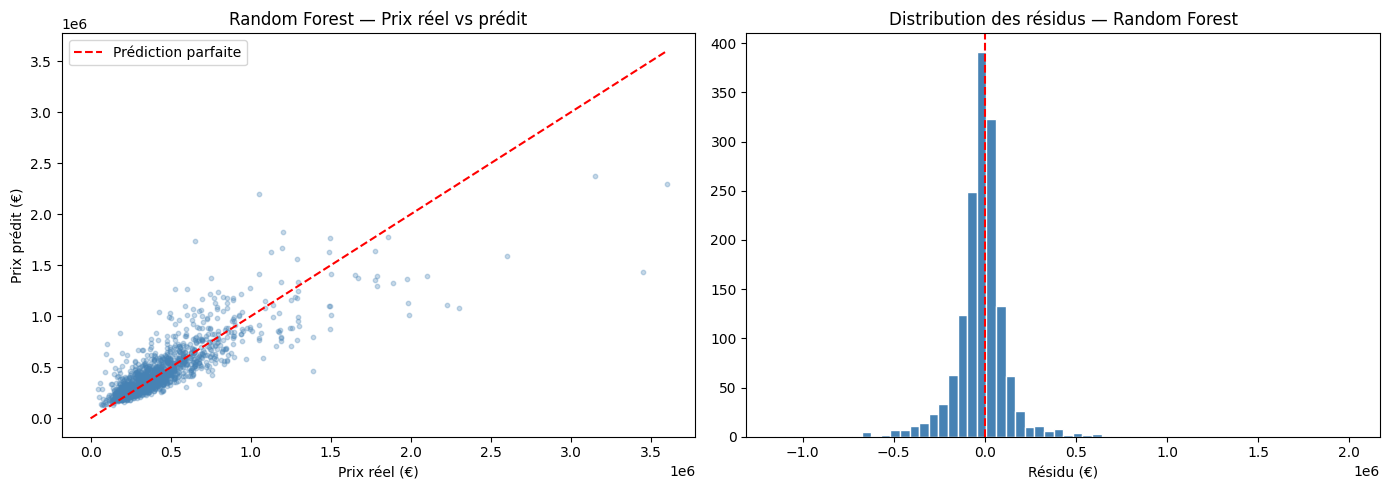

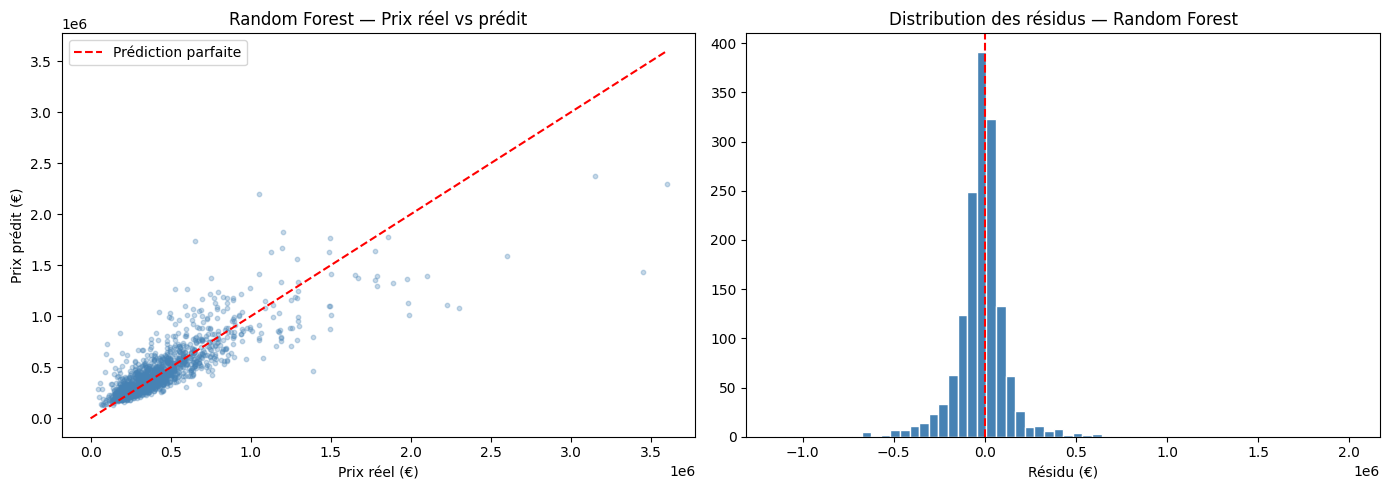

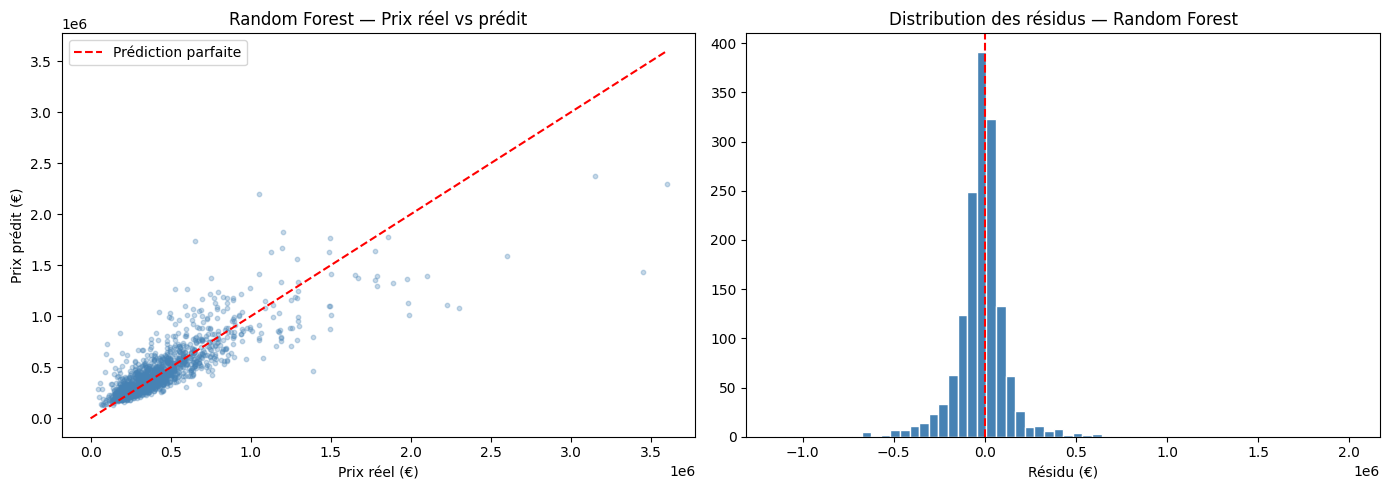

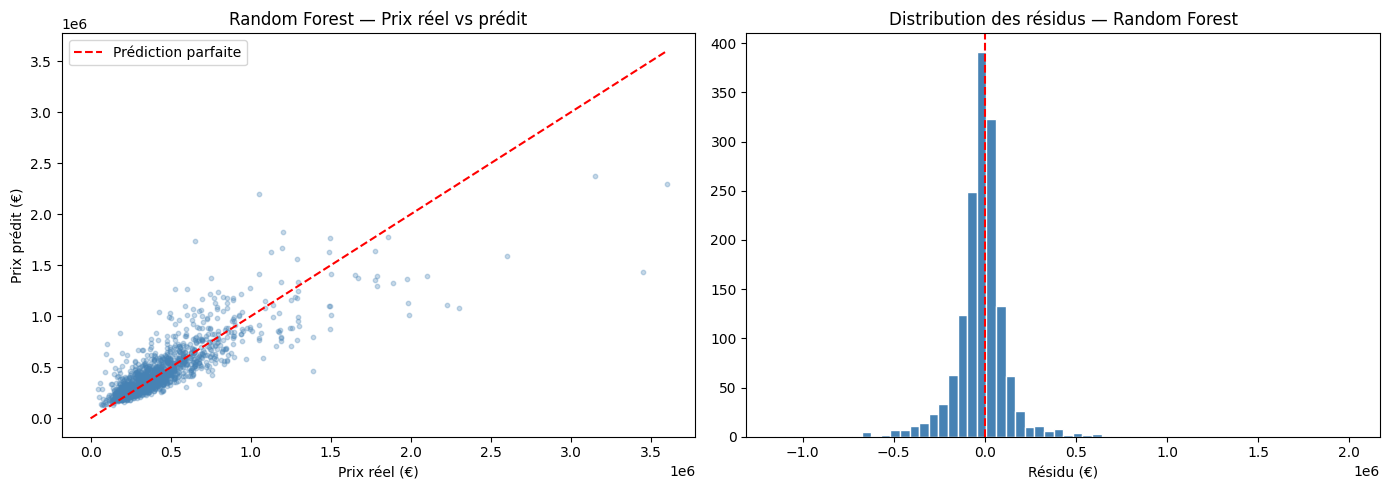

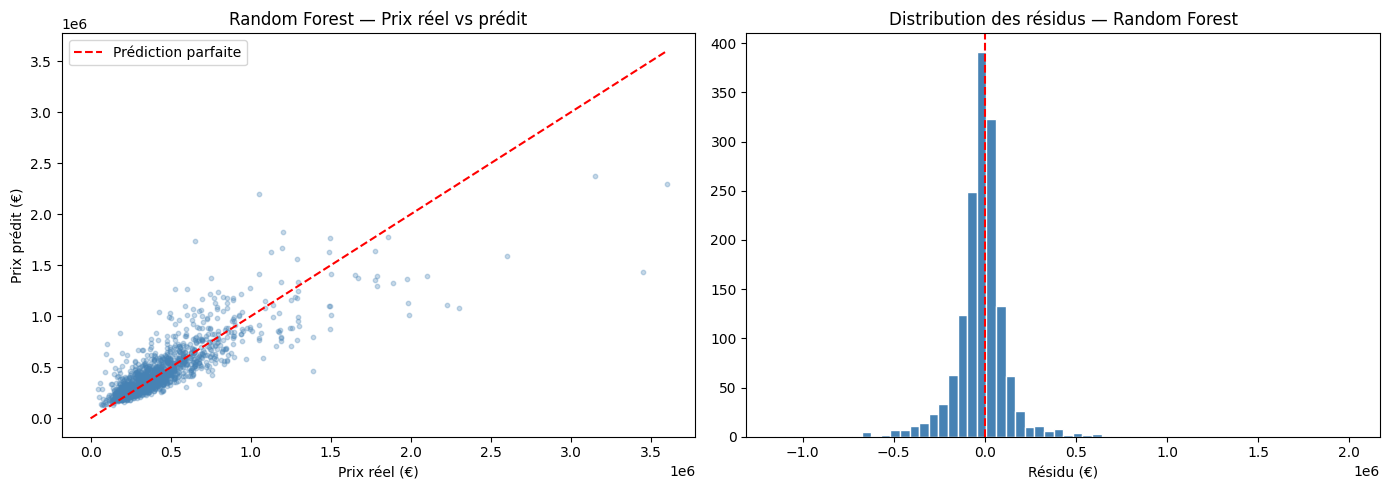

In [36]:

import matplotlib.pyplot as plt
%matplotlib inline
rf_pred_pd = rf_pred.select("prix", "prediction").toPandas()
rf_pred_pd["residus"] = rf_pred_pd["prix"] - rf_pred_pd["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rf_pred_pd["prix"], rf_pred_pd["prediction"], alpha=0.3, s=10, color='steelblue')
lim = max(rf_pred_pd["prix"].max(), rf_pred_pd["prediction"].max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Prédiction parfaite')
axes[0].set_xlabel("Prix réel (€)")
axes[0].set_ylabel("Prix prédit (€)")
axes[0].set_title("Random Forest — Prix réel vs prédit")
axes[0].legend()

axes[1].hist(rf_pred_pd["residus"], bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel("Résidu (€)")
axes[1].set_title("Distribution des résidus — Random Forest")

plt.tight_layout()
plt.savefig('residus_rf.png', dpi=150, bbox_inches='tight')
plt.show()